### Assignment-1

Importing all the required Libraries
```bash
numpy
sklearn
```

In [10]:
import sklearn as sk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib

## Question 1

In [20]:
import random
import hashlib
import pandas as pd

In [21]:
class Hash_Table:
    def __init__(self, m = 1, hashing = "default", p = 524287, a = random.randint(1, 524286)):
        if (hashing == "default"):
            self.hash_list = [[] for i in range(m)]
            self.p = p
            self.m = m
            self.a = a
        else:
            self.hash_dict = {}
            self.m = m
        
    def universal_hash_function(self, X):
        h_x = ((self.a * X) % self.p) % self.m
        self.insert_uni(h_x, X)
        return h_x
    
    def insert_uni(self, hash, X):
        self.hash_list[hash].append(X)
        
    def hash_md5_string(string):
        has = hashlib.sha256(string.encode('utf-8')).hexdigest()
        dec_from_hex = {'0':0, '1':1, '2':2, '3':3, '4':4, '5':5, '6':6, '7':7, '8':8, '9':9, 'a':10, 'b':11, 'c':12, 'd':13, 'e':14, 'f':15}
        to_dec = dec_from_hex[has[-4]]*16**3 + dec_from_hex[has[-3]]*16**2 + dec_from_hex[has[-2]]*16 + dec_from_hex[has[-1]]
        return to_dec

    def random_hash_function(self, X):
        h_x = int(self.m * random.random())
        self.insert_rand(h_x, X)
        return h_x
    
    def insert_rand(self, hash, X):
        if hash in self.hash_dict.keys():
            self.hash_dict[hash].append(X)
        else:
            self.hash_dict[hash] = [X]

In [22]:
hash_table = Hash_Table(m=10000)
hash_table.universal_hash_function(123456789)
print(hash_table.hash_list)

[[], [], [], [123456789], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []

In [23]:
df = pd.DataFrame(columns = ['String', 'HashVal'])
words = []
with open('words.txt', 'r') as f:
    words = f.readlines()

word_hash = []
has_vals = []

for w in words:
    temp = w
    if (w[-1] == '\n'):
        temp = w[:-1]
    word_hash.extend([temp])
    has_vals.extend([Hash_Table.hash_md5_string(temp)])

df['String'] = word_hash
df['HashVal'] = has_vals
df.to_csv('hash_values.csv', index = False)

In [24]:
# Q1 c)
m = 500000
uni = Hash_Table(m)
ran = Hash_Table(m, hashing = "random")

results = {"Universal Hashing": [], "Random Hashing": []}

for i in range(5):
    for j in range(1, m+1):
        uni.universal_hash_function(j)
        ran.random_hash_function(j)
    results["Universal Hashing"].append({'Max' : 0, 'Min' : m})
    for j in uni.hash_list:
        if (len(j) > results["Universal Hashing"][-1]['Max']):
            results["Universal Hashing"][-1]['Max'] = len(j)
        if (len(j) < results["Universal Hashing"][-1]['Min']):
            results["Universal Hashing"][-1]['Min'] = len(j)
            
    results["Random Hashing"].append({'Max' : 0, 'Min' : m})
    for key in ran.hash_dict.keys():
        l = len(ran.hash_dict[key])
        if (l > results["Random Hashing"][-1]['Max']):
            results["Random Hashing"][-1]['Max'] = l
        if (l < results["Random Hashing"][-1]['Min']):
            results["Random Hashing"][-1]['Min'] = l
    
    uni = Hash_Table(m)
    ran = Hash_Table(m, hashing = "random")
    
print(results)

{'Universal Hashing': [{'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}, {'Max': 2, 'Min': 0}], 'Random Hashing': [{'Max': 8, 'Min': 1}, {'Max': 10, 'Min': 1}, {'Max': 9, 'Min': 1}, {'Max': 8, 'Min': 1}, {'Max': 9, 'Min': 1}]}


In [25]:
def dec_to_bin(n):
    final = ''
    while (n > 0):
        result = n%2
        final = str(result) + final
        n = n//2
    return final

def Flajolet_Martin():
    words = []
    with open('words.txt', 'r') as f:
        words = f.readlines()

    has_vals = []

    for w in words:
        temp = w
        if (w[-1] == '\n'):
            temp = w[:-1]
        has_vals.extend([Hash_Table.hash_md5_string(temp)])
    
    for m in [32, 64, 128, 256, 512, 1024]:
        max_z = 0
        hash_table = Hash_Table(m)
        for i in has_vals:
            h_x = hash_table.universal_hash_function(i)
            bi = dec_to_bin(h_x)
            z = 0
            for k in range(len(bi)-1, -1, -1):
                if (bi[k] == '0'):
                    z += 1
                else:
                    break
            max_z = max(max_z, z)
            
        est = 2**(max_z + 0.5)
        print(f" Estimated number of distinct words for m = {m} is {est}")
        
Flajolet_Martin()

 Estimated number of distinct words for m = 32 is 22.627416997969522
 Estimated number of distinct words for m = 64 is 45.254833995939045
 Estimated number of distinct words for m = 128 is 90.50966799187809
 Estimated number of distinct words for m = 256 is 181.01933598375618
 Estimated number of distinct words for m = 512 is 362.03867196751236
 Estimated number of distinct words for m = 1024 is 724.0773439350247


## Question 2
Bloom Filter implementation


In [13]:
class BloomFilter:
    def __init__(self, size, hashfuncCnt):
        self.size = size            ## M : Size of bit array
        self.hashfuncCnt = hashfuncCnt ## K : Number of hash functions 
        self.bitArray = [0] * size

    def addElement(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            self.bitArray[hash] = 1

    def existCheck(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            if self.bitArray[hash] == 0:
                return False
        return True

    def hashFunction(self, element, seed):
        kHash = []
        for i in range(self.hashfuncCnt):
            hash = (hashlib.md5((str(element) + str(seed) + str(i)).encode()).hexdigest())
            kHash.append(int(hash, 16) % self.size)
        return kHash

In [16]:
bloom = BloomFilter(10000, 5)

# Insert elements
bloom.addElement("85123A")
bloom.addElement("71053")

# Check membership
print(bloom.existCheck("85123A"))  # True (should be)
print(bloom.existCheck("99999"))   # False (most likely)


True
False


In [8]:
retailDf = pd.read_csv('online-retail.csv')
print(retailDf['StockCode'].head())


0    85123A
1     71053
2    84406B
3    84029G
4    84029E
Name: StockCode, dtype: object


### Misa Gries Algorithm 
---
Frequency Estimation in a Data Stream
```
https://www.cs.dartmouth.edu/~ac/Teach/data-streams-lecnotes.pdf
```

In [2]:
class DataStream:
    def __init__(self, thresh: int):
        if thresh <= 0:
            raise ValueError("Threshold must be positive")
        self.thresh = thresh
        self.freq_map = {}

    ## ACTUAL Misra-Gries Algorithm implementation
    def addElement(self, element):
        if element in self.freq_map.keys():
            self.freq_map[element] += 1
        else:
            self.freq_map[element] = 1
        if len(self.freq_map) >= self.thresh:
            keys_to_remove = []
            for key in self.freq_map.keys():
                self.freq_map[key] -= 1
                if self.freq_map[key] == 0:
                    keys_to_remove.append(key)
            for key in keys_to_remove:
                del self.freq_map[key]

    def queryEle(self, element):
        if element in self.freq_map.keys():
            return self.freq_map.get(element,0)
    
    def freqElereturn(self):
        return self.freq_map
        


In [11]:
if __name__== "__main__":
    # patch the method
    dataStream = DataStream(thresh=4000)
    retailDf = pd.read_csv('online-retail.csv')
    stockCodes = retailDf['StockCode']
    
    # Calculate actual frequency of '22913' for debugging
    actual_freq = stockCodes.value_counts().get('22913', 0)
    print(f"Actual frequency of '22913' in dataset: {actual_freq}")
    
    for code in stockCodes:
        dataStream.addElement(code)

    queryCode = '22913'
    result = dataStream.queryEle(queryCode)
    print(f"Approximate frequency of '{queryCode}' from Misra-Gries: {result}")



Actual frequency of '22913' in dataset: 114
Approximate frequency of '22913' from Misra-Gries: 113


```

Direct Frequency count of each element in the Stream

```

In [16]:
dataframe = pd.read_csv('online-retail.csv')
stockCodes = dataframe['StockCode']
direct_freq_map = {}
for code in stockCodes:
    if code in direct_freq_map:
        direct_freq_map[code] += 1
    else:
        direct_freq_map[code] = 1

print("Direct frequency count of elements:")
print(len(direct_freq_map))
# for code, freq in direct_freq_map.items():
#     print(f"Element {code}: {freq}")
    


Direct frequency count of elements:
4070


# Question 3

In [26]:
# a)
from sklearn.datasets import fetch_kddcup99
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
def ToInt(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal

def cost(D, C):
    cost = 0
    for i in range(D.shape[0]):
        dist = np.linalg.norm(D[i] - C, axis=1)
        cost += min(dist)**2
    return cost

In [28]:
dataset = fetch_kddcup99(subset=None)
N = dataset.data.shape[0]
D = dataset.data.shape[1]

df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
print(df_normal)

DATA = df_normal.to_numpy()
DATA.shape

C:\Users\jonsn\AppData\Local\Temp\ipykernel_9156\2290841944.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


        0   1   2   3    4     5   6   7   8   9   ...  31   32     33   34  \
0        0   1  22   9  164  4773   0   0   0   0  ...   9    9  100.0  0.0   
1        0   1  22   9  222   465   0   0   0   0  ...  19   19  100.0  0.0   
2        0   1  22   9  218  1316   0   0   0   0  ...  29   29  100.0  0.0   
3        0   1  22   9  202  1316   0   0   0   0  ...  39   39  100.0  0.0   
4        0   1  22   9  200  2006   0   0   0   0  ...  49   49  100.0  0.0   
...     ..  ..  ..  ..  ...   ...  ..  ..  ..  ..  ...  ..  ...    ...  ...   
494016   0   1  22   9  293  1856   0   0   0   0  ...  86  255  100.0  0.0   
494017   0   1  22   9  265  2254   0   0   0   0  ...   6  255  100.0  0.0   
494018   0   1  22   9  186  1179   0   0   0   0  ...  16  255  100.0  0.0   
494019   0   1  22   9  274  1179   0   0   0   0  ...  26  255  100.0  0.0   
494020   0   1  22   9  202  1213   0   0   0   0  ...   6  255  100.0  0.0   

           35   36   37    38   39   40  
0        

(494021, 41)

In [ ]:
costs = []

for X in [5, 10, 15, 20, 25]:
    costs.extend([[]])
    for i in range(5):
        M = np.random.normal(0, 1/np.sqrt(X), size=(D, X))
        E = DATA @ M
        
        kE = KMeans(n_clusters=15)
        kE.fit(E)
        A = kE.cluster_centers_
        
        kDATA = KMeans(n_clusters=15)
        kDATA.fit(DATA)
        B = kDATA.cluster_centers_
        
        CostA = cost(DATA, A @ np.linalg.pinv(M))
        CostB = cost(DATA, B)
        costs[-1].append((CostA, CostB))

for i in range(len(costs)):
    for j in range(5):
        print(f'x = {(i+1)*5} Cost(A) : {costs[i][j][0]}, Cost(B) : {costs[i][j][1]}')

x = 5 Cost(A) : 1237586216305.2073 Cost(B) : 16656122730.422739
x = 5 Cost(A) : 1261275346901.6462 Cost(B) : 17112427980.779793
x = 5 Cost(A) : 1414012970888.2324 Cost(B) : 19795979474.90592
x = 5 Cost(A) : 1400427934253.8083 Cost(B) : 19561894800.086708
x = 5 Cost(A) : 1191129883782.7275 Cost(B) : 17274792568.39173
x = 10 Cost(A) : 1091219740171.9365 Cost(B) : 18010341086.165962
x = 10 Cost(A) : 897156199935.0723 Cost(B) : 16648756217.917751
x = 10 Cost(A) : 1086016828605.5522 Cost(B) : 17112398721.908554
x = 10 Cost(A) : 1016490261942.5363 Cost(B) : 19281284479.14198
x = 10 Cost(A) : 1066396222412.7312 Cost(B) : 16648710362.218502
x = 15 Cost(A) : 899285045633.5101 Cost(B) : 17112421118.328897
x = 15 Cost(A) : 878187551217.1042 Cost(B) : 16656102286.830769
x = 15 Cost(A) : 1072746737334.0848 Cost(B) : 17854568215.488052
x = 15 Cost(A) : 706528185519.0236 Cost(B) : 16590039803.721498
x = 15 Cost(A) : 758922948206.0131 Cost(B) : 17997728421.89691
x = 20 Cost(A) : 810817658218.8223 Cost

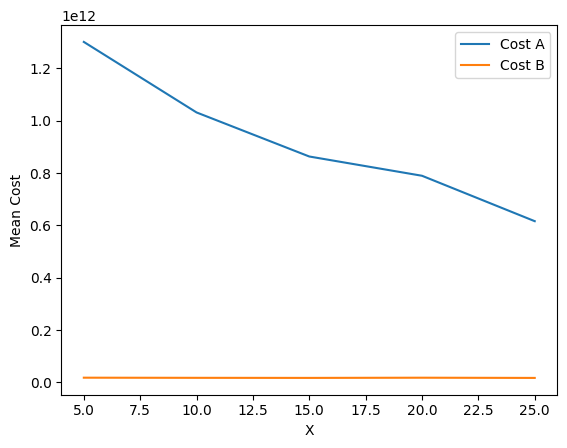

In [30]:
mean_costs_A = [np.mean([i[0] for i in cc]) for cc in costs]
mean_costs_B = [np.mean([i[1] for i in cc]) for cc in costs]
plt.plot([5, 10, 15, 20, 25], mean_costs_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], mean_costs_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.show()

In [ ]:
# b)
from sklearn.datasets import fetch_kddcup99
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [32]:
def ToInt(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal

def Losses(D, Y, C):
    loss = 0
    for i in range(D.shape[0]):
        pred = D[i] @ C.T
        loss += (pred - Y[i])**2
    return loss

In [33]:
dataset = fetch_kddcup99(subset=None)
N = dataset.data.shape[0]
D = dataset.data.shape[1]

df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
print(df_normal)

DATA = df_normal.to_numpy()
DATA.shape

C:\Users\jonsn\AppData\Local\Temp\ipykernel_9156\679658869.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


        0   1   2   3    4     5   6   7   8   9   ...  31   32     33   34  \
0        0   1  22   9  164  4773   0   0   0   0  ...   9    9  100.0  0.0   
1        0   1  22   9  222   465   0   0   0   0  ...  19   19  100.0  0.0   
2        0   1  22   9  218  1316   0   0   0   0  ...  29   29  100.0  0.0   
3        0   1  22   9  202  1316   0   0   0   0  ...  39   39  100.0  0.0   
4        0   1  22   9  200  2006   0   0   0   0  ...  49   49  100.0  0.0   
...     ..  ..  ..  ..  ...   ...  ..  ..  ..  ..  ...  ..  ...    ...  ...   
494016   0   1  22   9  293  1856   0   0   0   0  ...  86  255  100.0  0.0   
494017   0   1  22   9  265  2254   0   0   0   0  ...   6  255  100.0  0.0   
494018   0   1  22   9  186  1179   0   0   0   0  ...  16  255  100.0  0.0   
494019   0   1  22   9  274  1179   0   0   0   0  ...  26  255  100.0  0.0   
494020   0   1  22   9  202  1213   0   0   0   0  ...   6  255  100.0  0.0   

           35   36   37    38   39   40  
0        

(494021, 41)

In [34]:
Y = dataset.target
YLABEL = ToInt(pd.DataFrame(Y)).to_numpy()

C:\Users\jonsn\AppData\Local\Temp\ipykernel_9156\679658869.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


In [35]:
loss = []
# takes a lot of time, need to optimize
for X in [25, 50, 100, 200, 500]:
    loss.extend([[]])
    for j in tqdm(range(5)):
        s = 3
        M = np.zeros((X, N))
        for i in range(X):
            for j in range(N):
                r = np.random.rand()
                if r < 1/(2*s):
                    M[i, j] = np.sqrt(s)
                elif r < 1 - 1/(2*s):
                    M[i, j] = 0
                else:
                    M[i, j] = -np.sqrt(s)
        E = M @ DATA
        Z = M @ YLABEL
        
        lE = LinearRegression()
        lE.fit(E, Z)
        A = lE.coef_
    
        lDATA = LinearRegression()
        lDATA.fit(DATA, YLABEL)
        B = lDATA.coef_
        
        LossA = Losses(DATA, YLABEL, A)
        LossB = Losses(DATA, YLABEL, B)
        loss[-1].append((LossA, LossB))

for i in range(len(loss)):
    for j in range(5):
        print(f'x = {(i+1)*5} Loss(A) : {loss[i][j][0]}, Loss(B) : {loss[i][j][1]}')

x = 5 Loss(A) : [1196373.49916351], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [20483381.0675026], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [7736033.02948709], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [14229910.51264676], Loss(B) : [30559346.87276405]
x = 5 Loss(A) : [11012120.23675692], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1138776.59588534], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1761686.51744057], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1674316.124131], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1670079.26533165], Loss(B) : [30559346.87276405]
x = 10 Loss(A) : [1069758.81501531], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [714256.36383399], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [533636.15252417], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [505206.55828583], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [573886.70993473], Loss(B) : [30559346.87276405]
x = 15 Loss(A) : [461072.93815969], Loss(B) : [30559346.87276405]
x = 2

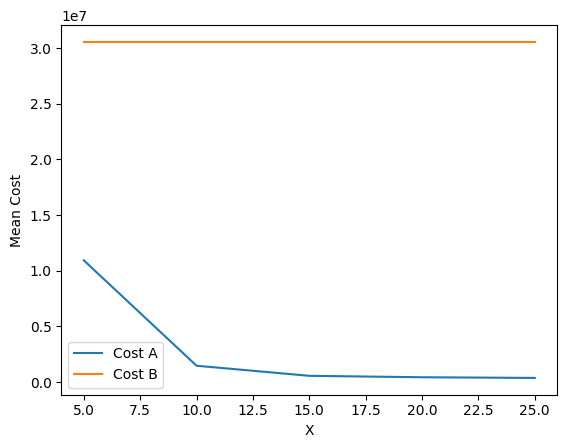

In [36]:
m_loss_A = [np.mean([i[0] for i in ll]) for ll in loss]
m_loss_B = [np.mean([i[1] for i in ll]) for ll in loss]
plt.plot([5, 10, 15, 20, 25], m_loss_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], m_loss_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.show()